In [13]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import joblib

In [14]:
COLUMNAS_ESPERADAS = [
    'diagnosis',  # Primera columna es el diagnóstico
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean',
    'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
    'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se',
    'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst',
    'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv("wdbc.csv", names=COLUMNAS_ESPERADAS)

In [15]:
# Convertir diagnosis a numérico
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separar X (características) e y (target)
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Verificar
print("Valores únicos en y:", y.unique())
print("Tipo de y:", y.dtype)

Valores únicos en y: [1 0]
Tipo de y: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
from sklearn.preprocessing import StandardScaler

# ...existing code...

# Opción 2: One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Ahora escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print(y.unique())

[1 0]


In [20]:
# Regresión logística
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)

# Red neuronal
nn_model = MLPClassifier(hidden_layer_sizes=(30, 30), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(30, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [21]:
print("Accuracy Regresión Logística:", log_model.score(X_test_scaled, y_test))
print("Accuracy Red Neuronal:", nn_model.score(X_test_scaled, y_test))

Accuracy Regresión Logística: 0.9736842105263158
Accuracy Red Neuronal: 0.9824561403508771


In [22]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones en conjunto de test
y_pred_log = log_model.predict(X_test_scaled)
y_pred_nn = nn_model.predict(X_test_scaled)

# Matriz de confusión para Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
print("=== REGRESIÓN LOGÍSTICA ===")
print("Matriz de Confusión:")
print(cm_log)
print(f"\nVerdaderos Positivos (VP): {cm_log[1][1]}")
print(f"Verdaderos Negativos (VN): {cm_log[0][0]}")
print(f"Falsos Positivos (FP): {cm_log[0][1]}")
print(f"Falsos Negativos (FN): {cm_log[1][0]}")

# Métricas para Regresión Logística
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"\nPrecisión: {precision_log:.4f} ({precision_log*100:.2f}%)")
print(f"Recall: {recall_log:.4f} ({recall_log*100:.2f}%)")
print(f"F1-Score: {f1_log:.4f}")
print(f"Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")

# Matriz de confusión para Red Neuronal
cm_nn = confusion_matrix(y_test, y_pred_nn)
print("\n=== RED NEURONAL ===")
print("Matriz de Confusión:")
print(cm_nn)
print(f"\nVerdaderos Positivos (VP): {cm_nn[1][1]}")
print(f"Verdaderos Negativos (VN): {cm_nn[0][0]}")
print(f"Falsos Positivos (FP): {cm_nn[0][1]}")
print(f"Falsos Negativos (FN): {cm_nn[1][0]}")

# Métricas para Red Neuronal
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print(f"\nPrecisión: {precision_nn:.4f} ({precision_nn*100:.2f}%)")
print(f"Recall: {recall_nn:.4f} ({recall_nn*100:.2f}%)")
print(f"F1-Score: {f1_nn:.4f}")
print(f"Accuracy: {accuracy_nn:.4f} ({accuracy_nn*100:.2f}%)")

=== REGRESIÓN LOGÍSTICA ===
Matriz de Confusión:
[[70  1]
 [ 2 41]]

Verdaderos Positivos (VP): 41
Verdaderos Negativos (VN): 70
Falsos Positivos (FP): 1
Falsos Negativos (FN): 2

Precisión: 0.9762 (97.62%)
Recall: 0.9535 (95.35%)
F1-Score: 0.9647
Accuracy: 0.9737 (97.37%)

=== RED NEURONAL ===
Matriz de Confusión:
[[71  0]
 [ 2 41]]

Verdaderos Positivos (VP): 41
Verdaderos Negativos (VN): 71
Falsos Positivos (FP): 0
Falsos Negativos (FN): 2

Precisión: 1.0000 (100.00%)
Recall: 0.9535 (95.35%)
F1-Score: 0.9762
Accuracy: 0.9825 (98.25%)


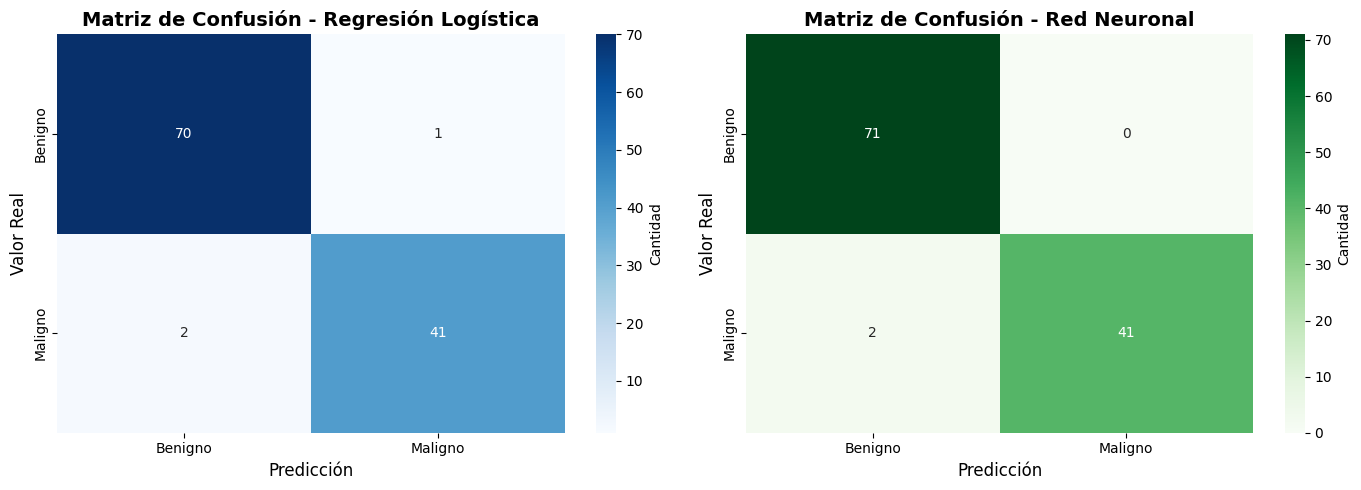

In [23]:
# Visualizar matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión para Regresión Logística
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Benigno', 'Maligno'], 
            yticklabels=['Benigno', 'Maligno'],
            cbar_kws={'label': 'Cantidad'})
axes[0].set_title('Matriz de Confusión - Regresión Logística', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Predicción', fontsize=12)

# Matriz de confusión para Red Neuronal
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benigno', 'Maligno'], 
            yticklabels=['Benigno', 'Maligno'],
            cbar_kws={'label': 'Cantidad'})
axes[1].set_title('Matriz de Confusión - Red Neuronal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valor Real', fontsize=12)
axes[1].set_xlabel('Predicción', fontsize=12)

plt.tight_layout()
plt.show()

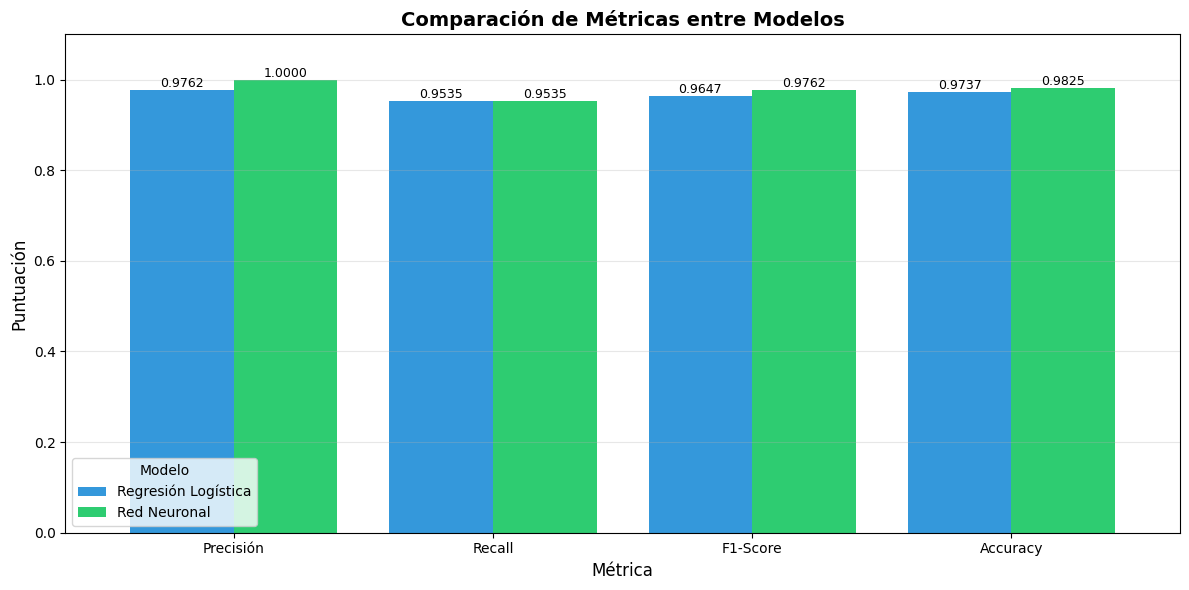


=== RESUMEN COMPARATIVO ===
                     Precisión  Recall  F1-Score  Accuracy
Regresión Logística     0.9762  0.9535    0.9647    0.9737
Red Neuronal            1.0000  0.9535    0.9762    0.9825


In [24]:
# Comparar métricas entre modelos
metricas_comparacion = {
    'Precisión': [precision_log, precision_nn],
    'Recall': [recall_log, recall_nn],
    'F1-Score': [f1_log, f1_nn],
    'Accuracy': [accuracy_log, accuracy_nn]
}

df_metricas = pd.DataFrame(metricas_comparacion, index=['Regresión Logística', 'Red Neuronal'])

# Gráfica de comparación
fig, ax = plt.subplots(figsize=(12, 6))
df_metricas.T.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'], width=0.8)
ax.set_title('Comparación de Métricas entre Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_xlabel('Métrica', fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(title='Modelo', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n=== RESUMEN COMPARATIVO ===")
print(df_metricas.round(4))

In [26]:
joblib.dump(log_model, "log_model.pkl")
joblib.dump(nn_model, "nn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [27]:
# Simular un dato real
sample = X.iloc[0].values.reshape(1, -1)

sample_scaled = scaler.transform(sample)

print("Log:", log_model.predict(sample_scaled)[0])
print("NN:", nn_model.predict(sample_scaled)[0])
print("Prob NN:", nn_model.predict_proba(sample_scaled)[0][1])

Log: 1
NN: 1
Prob NN: 0.9999999999999867


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
